In [1]:
# GPU check
!nvidia-smi

# Clone Real-ESRGAN repository aur dependencies install karein
!git clone https://github.com/xinntao/Real-ESRGAN.git
%cd Real-ESRGAN
!pip install basicsr facexlib gfpgan
!pip install -r requirements.txt
!python setup.py develop

Thu Mar 12 11:11:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import os
import sys

# basicsr library ka installation path directly set karna
# Hum jante hain ki yeh /usr/local/lib/python3.12/dist-packages mein install hua hai
basicsr_install_path = None
for p in sys.path:
    if "dist-packages" in p and os.path.exists(os.path.join(p, "basicsr")):
        basicsr_install_path = os.path.join(p, "basicsr")
        break

if basicsr_install_path is None:
    # Fallback if the path isn't found in sys.path (unlikely after successful pip install)
    # Yeh path standard Google Colab environment ke liye hai
    basicsr_install_path = "/usr/local/lib/python3.12/dist-packages/basicsr"

deg_file = os.path.join(basicsr_install_path, 'data', 'degradations.py')

# File ko open kar ke galat import ko theek karna
if os.path.exists(deg_file):
    with open(deg_file, 'r') as f:
        content = f.read()

    # Sirf tab replace karein jab purana wala import string maujood ho
    old_import = 'from torchvision.transforms.functional_tensor import rgb_to_grayscale'
    new_import = 'from torchvision.transforms.functional import rgb_to_grayscale'

    if old_import in content:
        content = content.replace(old_import, new_import)

        # Theek kiya hua code wapis save karna
        with open(deg_file, 'w') as f:
            f.write(content)
        print("✅ basicsr degradations.py file updated successfully!")
    else:
        print("ℹ️ basicsr degradations.py file mein pehle se hi sahi import hai ya badlav ki zaroorat nahi hai.")
else:
    print(f"❌ Error: degradations.py file '{deg_file}' nahi mila.")

# Ab basicsr ko import karne ki koshish karein taaki verify ho sake ki fix kaam kar gaya.
try:
    import basicsr
    print("✅ basicsr successfully imported after fix.")
    print("Ab aap apna upscaling wala code dobara run kar sakte hain.")
except ModuleNotFoundError as e:
    print(f"❌ basicsr import abhi bhi fail ho raha hai: {e}")

✅ basicsr degradations.py file updated successfully!
✅ basicsr successfully imported after fix.
Ab aap apna upscaling wala code dobara run kar sakte hain.


🚀 Upscaling started using RealESRGAN_x4plus_anime_6B...
Testing 0 input
✅ Image exactly 3840x2160 resolution pe resize ho gayi hai.
🎉 Upscaling Complete!
📊 Before & After preview generate ho raha hai...


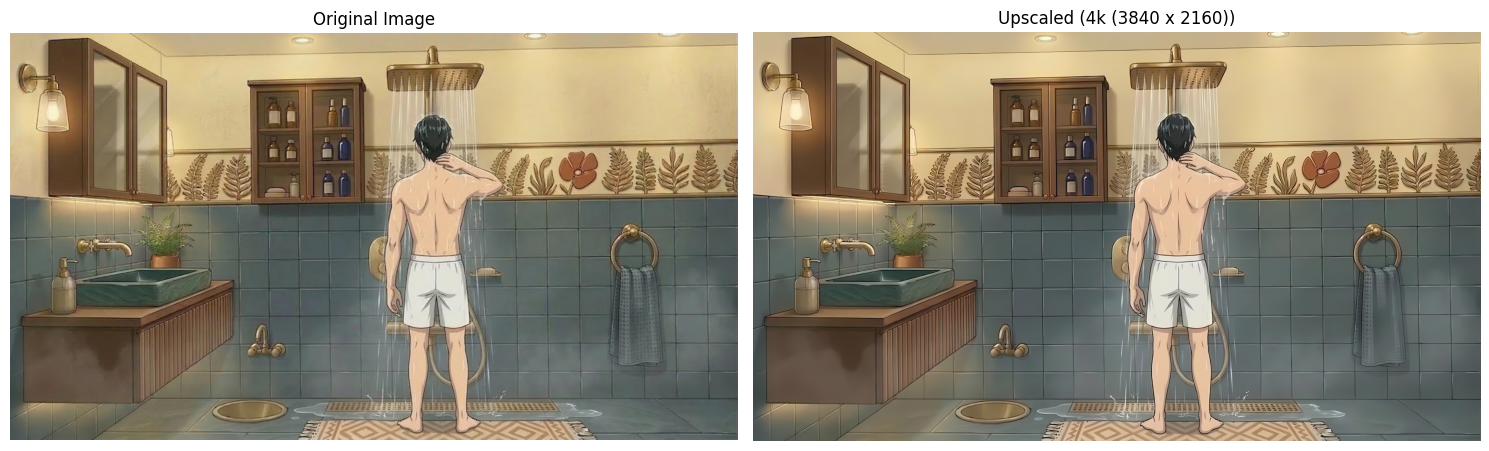

In [7]:
import os
import cv2
import matplotlib.pyplot as plt

#@title 🎨 Single Image Upscaler (Auto-PNG + Before & After View)
image_path = "/content/input.png" #@param {type:"string"}
output_dir = "/content/" #@param {type:"string"}
resolution = "4k (3840 x 2160)" #@param ["FHD (1920 x 1080)", "2k (2560 x 1440)", "4k (3840 x 2160)", "8k (7680 x 4320)", "2 x original", "3 x original", "4 x original"]
model = "RealESRGAN_x4plus_anime_6B" #@param ["RealESRGAN_x4plus", "RealESRNet_x4plus", "RealESRGAN_x4plus_anime_6B", "realesr-animevideov3"]
show_comparison = True #@param {type:"boolean"}

# Output directory create karna
os.makedirs(output_dir, exist_ok=True)

# 🔄 AUTO-CONVERT LOGIC
if not image_path.lower().endswith('.png'):
    print("🔄 Image format check ho raha hai...")
    img_temp = cv2.imread(image_path)
    if img_temp is not None:
        new_path = os.path.splitext(image_path)[0] + '.png'
        cv2.imwrite(new_path, img_temp)
        image_path = new_path
        print(f"✅ Image ko PNG mein convert kar diya gaya hai: {image_path}")

# CLI ke liye scale factor set karna
scale_factor = 4
if "2 x" in resolution:
    scale_factor = 2
elif "3 x" in resolution:
    scale_factor = 3

print(f"🚀 Upscaling started using {model}...")

# Real-ESRGAN command run karna
!python inference_realesrgan.py -n {model} -i {image_path} -o {output_dir} -s {scale_factor} --ext png

# Output file ka path set karna
filename = os.path.basename(image_path)
name, ext = os.path.splitext(filename)
out_path = os.path.join(output_dir, f"{name}_out.png")

# Exact dimensions pe resize karna
if "original" not in resolution:
    res_str = resolution.split("(")[1].split(")")[0]
    target_w, target_h = map(int, res_str.split(" x "))

    img = cv2.imread(out_path)
    if img is not None:
        resized_img = cv2.resize(img, (target_w, target_h), interpolation=cv2.INTER_CUBIC)
        cv2.imwrite(out_path, resized_img)
        print(f"✅ Image exactly {target_w}x{target_h} resolution pe resize ho gayi hai.")

print("🎉 Upscaling Complete!")

# 🖼️ BEFORE & AFTER VIEW LOGIC
if show_comparison:
    print("📊 Before & After preview generate ho raha hai...")
    img_orig = cv2.imread(image_path)
    img_up = cv2.imread(out_path)

    if img_orig is not None and img_up is not None:
        # OpenCV BGR format use karta hai, Matplotlib RGB use karta hai. Is liye convert karna zaroori hai.
        img_orig = cv2.cvtColor(img_orig, cv2.COLOR_BGR2RGB)
        img_up = cv2.cvtColor(img_up, cv2.COLOR_BGR2RGB)

        # Plot generate karna
        fig, ax = plt.subplots(1, 2, figsize=(15, 8))
        ax[0].imshow(img_orig)
        ax[0].set_title('Original Image')
        ax[0].axis('off')

        ax[1].imshow(img_up)
        ax[1].set_title(f'Upscaled ({resolution})')
        ax[1].axis('off')

        plt.tight_layout()
        plt.show()
    else:
        print("❌ Preview generate nahi ho saka, file read error.")